# 00 — One-Shot Fully-Automated Calibration

**The fastest path from raw image to a usable detector calibration.**

If you have:
* a calibrant image (CeO₂, LaB₆, Si, Al₂O₃, …)
* the X-ray wavelength
* the pixel pitch

… that is enough for the v2 pipeline to:

1. **Seed** the beam centre and sample–detector distance from the rings (no manual guess).
2. **Refine** all 5 geometry parameters and the 15-coefficient harmonic distortion via the differentiable LM engine.
3. **Build the empirical residual-correction map** that closes the last ~50–100 µε gap vs. the v1 C reference.
4. **Save** a v1-compatible `residual_corr.bin` and a JSON summary, both directly consumable by `midas_integrate`, `midas_integrate_v2`, and `CalibrantIntegratorOMP`.

All of that is one function call:

```python
result = calibrate(image, wavelength=..., pxY=..., dark=..., calibrant=...)
```

End-to-end runtime on a 2880² Perkin-Elmer image is ~5 minutes on CPU and a few seconds for the seed stage.

## 1. Environment + load a calibrant image

Any 2-D numpy array works.  This notebook reads an HDF5 file, but `.tif` / `.zarr` / GE-binary are all fine — `calibrate()` accepts an array.

In [ ]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from pathlib import Path
import h5py, numpy as np

# Point this at a calibrant image you have.  The example file used here
# is a 2-second CeO2 exposure on a Perkin-Elmer 2880x2880 @ 150 um at 1ID.
DATA = Path(os.environ.get(
    'V2_ONESHOT_FILE',
    '/Users/hsharma/Desktop/analysis/leighanne/data/CeO2_XRD_echem_JLi_002587.vrx.h5',
))
assert DATA.exists(), f'set V2_ONESHOT_FILE or update the DATA path; missing {DATA}'

with h5py.File(DATA, 'r') as f:
    img  = f['exchange/data'][0].astype(np.float32)
    dark = f['exchange/data_dark'][0].astype(np.float32)
print(f'image  : shape={img.shape}  dtype={img.dtype}  mean={img.mean():.1f}')
print(f'dark   : shape={dark.shape}  mean={dark.mean():.1f}')

## 2. One function call — `calibrate(...)` does everything

Required inputs:

| arg | meaning |
|---|---|
| `image` | 2-D array, MIDAS convention `(NrPixelsZ, NrPixelsY)` |
| `wavelength` | Å (e.g. 0.184139 for 67.332 keV) |
| `pxY` | µm; if pixels aren't square also pass `pxZ` |

Optional:

| arg | default | what it does |
|---|---|---|
| `dark` | None | subtracted from `image` |
| `calibrant` | `"CeO2"` | `"CeO2"` / `"LaB6"` / `"Si"` / `"Al2O3"`, or a dict `{"a":..., "sg":...}` |
| `im_trans` | `()` | MIDAS image transforms applied up front to image+dark: `1`=flip Y, `2`=flip Z, `3`=transpose. Pass e.g. `(2,)` when the detector frame is Z-flipped relative to the geometry model |
| `panel_layout` | None | a `PanelLayout` for tiled-module detectors (Pilatus/Eiger). When set, `calibrate()` runs a two-phase flow: monolithic geometry first, then per-panel refinement with the global geometry frozen — see NB 03 |
| `panel_mode` | `"radius"` | with `panel_layout`: `"radius"` refines a per-(panel,ring) δR (nulls the radial residual cell-by-cell); `"shift"` refines rigid per-panel (δy, δz, δθ) |
| `output_dir` | None | writes `calibration.json` + `residual_corr.bin` |
| `build_residual_corr` | True | port of v1 C `dg_residual_corr_lookup` |
| `device` | `"cpu"` | `"cuda"` for the LM step (seed stays on CPU) |

The internal `RhoD` (distortion normalisation radius) is **auto-resolved to µm** by `resolve_rho_d_um`: it detects whether the value you supplied is in pixels or µm and converts, defaulting to the beam-centre-to-farthest-corner distance when none is given — so a wrong-unit value is silently corrected rather than silently breaking the distortion model.

In [ ]:
from midas_calibrate_v2 import calibrate

result = calibrate(
    img,
    wavelength=0.184139,           # Å — the only physics input
    pxY=150.0,                     # µm
    dark=dark,                     # optional but recommended
    calibrant='CeO2',              # name or {'a':..., 'sg':...} dict
    output_dir='./calib_out',      # writes residual_corr.bin + calibration.json
)

## 3. Inspect the result

The `AutoCalibrationResult` object carries the full refined state plus all the provenance you need to reproduce, plot, or debug.

In [ ]:
print(f'GEOMETRY (refined)')
print(f'  Lsd    = {result.Lsd:.3f} \u00b5m  ({result.Lsd/1000:.3f} mm)')
print(f'  BC     = ({result.BC_y:.4f}, {result.BC_z:.4f})')
print(f'  tilts  = tx={result.tx:+.4f}\u00b0  ty={result.ty:+.4f}\u00b0  tz={result.tz:+.4f}\u00b0')
print(f'  px     = ({result.pxY}, {result.pxZ}) \u00b5m')
print(f'  detector size = {result.NrPixelsY}\u00d7{result.NrPixelsZ}')
print()
print(f'QUALITY')
print(f'  in-loop strain (last LM iter) : {result.in_loop_strain_uE:.1f} \u00b5\u03b5')
print(f'  post-residual strain           : {result.post_residual_strain_uE:.1f} \u00b5\u03b5')
print()
print(f'SEED PROVENANCE  (auto BC/Lsd before LM)')
print(f'  seed BC = ({result.seed_BC_y:.2f}, {result.seed_BC_z:.2f})')
print(f'  seed Lsd = {result.seed_Lsd/1000:.3f} mm')
print(f'  seed time: {result.seed_seconds:.1f} s   refine time: {result.refine_seconds:.1f} s')
print()
print(f'DISTORTION (refined harmonics)')
for name, val in list(result.distortion.items())[:8]:
    print(f'  {name:8s} = {val:+.4e}')
print()
print(f'OUTPUTS')
print(f'  residual map: shape={tuple(result.residual_corr_map.shape)} dtype={result.residual_corr_map.dtype}')
print(f'  binary file : {result.residual_corr_bin_path}')

## 4. Visual sanity check — predicted rings should sit on the bright peaks

Always look at this.  Numbers can be wrong while passing all unit tests; the eye catches it instantly.

In [ ]:
from midas_hkls import SpaceGroup, Lattice, generate_hkls
import math, matplotlib.pyplot as plt

# Predict CeO₂ ring positions at the refined geometry using the same
# extinction rules midas_calibrate_v2 uses internally.
refs = generate_hkls(
    SpaceGroup.from_number(225),
    Lattice(a=5.4116, b=5.4116, c=5.4116, alpha=90.0, beta=90.0, gamma=90.0),
    wavelength_A=result.wavelength_A, two_theta_max_deg=14.0,
)
ring_R = [result.Lsd * math.tan(math.radians(r.two_theta_deg)) / result.pxY for r in refs]

img_d = np.clip(img - dark, 0, None)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(np.log1p(img_d.clip(min=1)), origin='lower', cmap='gray',
          vmin=np.log1p(np.percentile(img_d[img_d>0], 60)),
          vmax=np.log1p(np.percentile(img_d[img_d>0], 99.95)))
th = np.linspace(0, 2*np.pi, 360)
for r in ring_R[:12]:
    ax.plot(result.BC_y + r*np.cos(th), result.BC_z + r*np.sin(th),
            '-', color='lime', lw=0.7, alpha=0.85)
ax.plot(result.BC_y, result.BC_z, 'ro', ms=8, mec='yellow', label='BC')
ax.set_title(f'CeO₂ image + predicted rings at refined geometry\n'
             f'Lsd={result.Lsd/1000:.2f} mm  BC=({result.BC_y:.1f}, {result.BC_z:.1f})  '
             f'strain={result.post_residual_strain_uE:.0f} µε')
ax.set_xlim(0, result.NrPixelsY); ax.set_ylim(0, result.NrPixelsZ)
ax.legend(); plt.tight_layout(); plt.show()


## 5. The residual-correction map

Empirical smooth $\Delta R(Y, Z)$ field that absorbs systematic deviations the harmonic distortion model can't capture — the v2 port of v1 C's `dg_residual_corr_lookup`. Differentiable via `torch.nn.functional.grid_sample`; storage is bit-identical to the binary v1 produces, so the same `.bin` file flows downstream into all three packages.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
cm = result.residual_corr_map.cpu().numpy()
vlim = float(np.percentile(np.abs(cm), 99))
im = ax.imshow(cm, origin='lower', cmap='RdBu_r', vmin=-vlim, vmax=vlim)
ax.plot(result.BC_y, result.BC_z, 'ko', ms=6)
ax.set_title(f'Residual correction map \u0394R(Y, Z) in pixels\n'
             f'rms = {float(np.sqrt((cm**2).mean())):.3f} px,  '
             f'range = [{cm.min():.3f}, {cm.max():.3f}] px')
plt.colorbar(im, ax=ax, label='\u0394R (px)')
plt.tight_layout(); plt.show()

## 6. Cross-package handoff

The `residual_corr.bin` is the same wire format as v1 C. Load it directly with `midas_integrate` or `midas_integrate_v2`:

In [ ]:
# Roundtrip check: load the binary back into both packages.
from midas_calibrate_v2.forward.residual_corr import load_residual_corr_bin
v2_load = load_residual_corr_bin(result.residual_corr_bin_path,
                                  NrPixelsY=result.NrPixelsY,
                                  NrPixelsZ=result.NrPixelsZ)
print('midas_calibrate_v2 roundtrip max diff:',
      float((v2_load - result.residual_corr_map).abs().max()))

try:
    from midas_integrate.residual_corr import load_residual_correction_map
    v1 = load_residual_correction_map(result.residual_corr_bin_path,
                                       NrPixelsY=result.NrPixelsY,
                                       NrPixelsZ=result.NrPixelsZ)
    print('midas_integrate roundtrip max diff   :',
          float(np.max(np.abs(v1.map - result.residual_corr_map.cpu().numpy()))))
except ImportError:
    print('midas_integrate not installed — skipped')

## 7. When the one-shot path isn't enough

* Multi-distance setup (sample moved between two exposures): use **NB 07 — multi-distance**.
* Want σ on every parameter (Bayesian uncertainty): **NB 02 / NB 11**.
* Multi-panel detectors (Pilatus / Eiger): the one-shot call handles them directly — build a layout and pass it:
  ```python
  from midas_calibrate_v2.forward.panels import PanelLayout
  layout = PanelLayout.regular(n_y=6, n_z=8, sy=243, sz=195,
                               gap_y=(1, 7, 1, 7, 1), gap_z=17)
  result = calibrate(img, wavelength=..., pxY=172.0, dark=dark, im_trans=(2,),
                     panel_layout=layout, panel_mode='radius')
  ```
  `panel_mode='radius'` refines a per-(panel,ring) radial offset (the default, best for the radial calibrant cost); `panel_mode='shift'` refines rigid per-panel (δy, δz, δθ). For the low-level spec path + per-panel Bayesian σ, see **NB 03**.
* Non-cubic calibrant (corundum etc.): pass a `dict` with `a`, `c`, `alpha`, `gamma`, `sg`.
* First-time calibration with no good initial guess: **NB 06**.
* Refining only a subset (e.g. Lsd locked, only BC + tilts free): use `autocalibrate` directly with a custom `Refine` dict.

## 8. If `calibrate()` fails to find a good seed — use `auto_seed`

`calibrate()` includes an automatic seeder that locates the beam centre
and sample-to-detector distance (Lsd) from the calibrant image itself.
On most fine-powder images this works without any input from the user.
It can fail, however, when the image has unusual noise characteristics:

| Symptom | Likely cause |
|---|---|
| Final Lsd wildly wrong (×2–4 off the expected value) | Seeder picked the wrong ring family as its anchor |
| `calibrate()` raises with "no ring arcs survived" | Noise threshold too tight or too loose for this detector |
| Predicted rings (section 4) clearly miss the actual rings | Bad beam-centre estimate from the seeder |

In these cases `midas_calibrate_v2.seed.auto_seed.make_seed` provides
a more robust alternative seed. It uses a sentinel-aware, median-filter
background-subtract and a composite-score ring-index assignment that
adapt automatically to detector size and noise level.
The result — `(BC_y, BC_z, Lsd_um)` — is passed back into `calibrate()`
via the `initial_BC_y` / `initial_BC_z` / `initial_Lsd` keyword
arguments, which skip the built-in seeder and start the LM refinement
directly from the supplied values.

In [ ]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from pathlib import Path
import math
import h5py, numpy as np
import matplotlib.pyplot as plt

from midas_calibrate_v2 import calibrate
from midas_calibrate_v2.seed.auto_seed import make_seed
from midas_hkls import SpaceGroup, Lattice, generate_hkls

# Load the calibrant image — same file as section 1. Self-contained: this
# cell can be run without running any earlier cells in the notebook.
DATA = Path(os.environ.get(
    'V2_ONESHOT_FILE',
    '/Users/hsharma/Desktop/analysis/leighanne/data/CeO2_XRD_echem_JLi_002587.vrx.h5',
))
assert DATA.exists(), f'set V2_ONESHOT_FILE or update the DATA path; missing {DATA}'

with h5py.File(DATA, 'r') as f:
    img  = f['exchange/data'][0].astype(np.float32)
    dark = f['exchange/data_dark'][0].astype(np.float32)

# Step 1 — compute a robust (BC, Lsd) seed from the same image already loaded above.
# This takes a few seconds and requires no additional input from the user.
seed = make_seed(
    img,                       # same array as in section 1 — dark already subtracted
    wavelength_A = 0.184139,   # Å  — match the value you passed to calibrate()
    px_um        = 150.0,      # µm — match pxY
    calibrant    = 'CeO2',     # or 'LaB6', 'Si', 'Al2O3'
    # Optional tuning knobs (defaults work for most images):
    # snr_threshold       = 4.0,   # σ multiplier; lower → more arcs detected
    # bright_fraction_cap = 0.01,  # cap bright pixels at top 1 % of residual
    # min_arc_fraction    = 0.10,  # min arc length = 10 % of smallest image dim
    # dilation_radius     = 0,     # >0 bridges gaps in fragmented arcs
)
print(seed)
print()
print(f'  BC_y (column) = {seed.BC_y:.2f} px')
print(f'  BC_z (row)    = {seed.BC_z:.2f} px')
print(f'  Lsd           = {seed.Lsd_um / 1000:.3f} mm')

# Step 2 — re-run calibrate() with the seed, bypassing the built-in seeder.
result_with_seed = calibrate(
    img,
    wavelength   = 0.184139,
    pxY          = 150.0,
    dark         = dark,
    calibrant    = 'CeO2',
    initial_BC_y = seed.BC_y,      # ← from make_seed
    initial_BC_z = seed.BC_z,      # ← from make_seed
    initial_Lsd  = seed.Lsd_um,    # ← from make_seed
    output_dir   = './calib_out',
)

print()
print(f'Lsd  = {result_with_seed.Lsd / 1000:.4f} mm')
print(f'BC   = ({result_with_seed.BC_y:.2f}, {result_with_seed.BC_z:.2f}) px')
print(f'ty   = {result_with_seed.ty:+.4f}°   tz = {result_with_seed.tz:+.4f}°')
_s = (f'{result_with_seed.in_loop_strain_uE:.1f} µε'
      if result_with_seed.in_loop_strain_uE is not None else 'n/a')
print(f'in-loop strain = {_s}')

# Step 3 — visual check (same as section 4, using the new result).
refs = generate_hkls(
    SpaceGroup.from_number(225),
    Lattice(a=5.4116, b=5.4116, c=5.4116, alpha=90., beta=90., gamma=90.),
    wavelength_A=result_with_seed.wavelength_A, two_theta_max_deg=14.0,
)
ring_R2 = [result_with_seed.Lsd * math.tan(math.radians(r.two_theta_deg))
           / result_with_seed.pxY for r in refs]

img_d = np.clip(img - dark, 0, None) if dark is not None else img.copy()
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(np.log1p(img_d.clip(min=1)), origin='lower', cmap='gray',
          vmin=np.log1p(np.percentile(img_d[img_d > 0], 60)),
          vmax=np.log1p(np.percentile(img_d[img_d > 0], 99.95)))
th = np.linspace(0, 2 * np.pi, 360)
for r in ring_R2[:12]:
    if 0 < r < max(result_with_seed.NrPixelsY, result_with_seed.NrPixelsZ):
        ax.plot(result_with_seed.BC_y + r * np.cos(th),
                result_with_seed.BC_z + r * np.sin(th),
                '-', color='lime', lw=0.7, alpha=0.9)
ax.plot(result_with_seed.BC_y, result_with_seed.BC_z,
        'ro', ms=8, mec='yellow', label='refined BC')
ax.set_title(
    f'Predicted rings at geometry refined with auto_seed\n'
    f'Lsd = {result_with_seed.Lsd / 1000:.2f} mm  '
    f'BC = ({result_with_seed.BC_y:.1f}, {result_with_seed.BC_z:.1f})  '
    f'strain = {_s}')
ax.set_xlim(0, result_with_seed.NrPixelsY)
ax.set_ylim(0, result_with_seed.NrPixelsZ)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Same as section 8, but with a custom calibrant

Everything below follows the same `make_seed` + `calibrate()` flow as
section 8, but on a **different image and calibrant** to show the custom
calibrant dict end-to-end on real data:

* image: `scratch/test_calibrate_v2/data/ANLXRD00007_pos0.tif` (a LaB₆ exposure)
* wavelength: 0.2522 Å
* pixel pitch: 150 µm
* no dark frame for this dataset

Since `LaB6` happens to already be one of `make_seed`'s 4 built-in named
calibrants, this could just pass `calibrant='LaB6'` — but here we instead
describe it with a plain `dict`, exactly as documented in section 2, to
demonstrate the general custom-calibrant path:

```python
calibrant = {"a": 4.15704, "sg": 221}   # a in Å, sg = space-group number
```

(values from `scratch/test_calibrate_v2/data/info.txt`). Optional keys `b`,
`c` (default to `a`), `alpha`, `beta` (default to `alpha`), and `gamma`
(default 90°) let this describe any Bravais lattice midas_hkls supports —
not just the 4 built-in named calibrants (`CeO2`, `LaB6`, `Si`, `Al2O3`).

Two things to note:

* when `calibrant` is a dict, `make_seed` returns
  `seed.calibrant_name == "<custom>"` — that placeholder must **not** be fed
  back into `calibrate()` as a name. Pass the original dict instead, as done
  below.
* `make_seed` is called with `use_diplib=False` — on macOS, `diplib`'s
  median filter (the default background-subtract path) segfaults the whole
  process rather than raising a catchable exception; the scipy fallback is
  equally accurate.

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org
 |   MIDAS auto-seeder for BC and Lsd has been launched.
Seed(BC=(1454.60, 1432.75) px, Lsd=1000.239 mm, first_ring=1, n=5, rms=0.031 px, t=7.3s)

  BC_y (column) = 1454.60 px
  BC_z (row)    = 1432.75 px
  Lsd           = 1000.239 mm
  calibrant_name = '<custom>'  (placeholder — do not feed back as a name)
[calibrate] STAGE 1: seeding from <custom> rings...
[calibrate]   user-provided BC=(1454.596, 1432.753)  Lsd=1000.239 mm — auto-seed bypassed
[calibrate]   BC=(1454.596, 1432.753)  Lsd=1000.239 mm  (0 arcs, 0 ring matches, 0.0s)
[calibrate] STAGE 2: autocalibrate + residual map...
[autocalibrate] RhoD resolved to 307682.1 µm (×px (was pixels))


/Users/dbeniwal/anaconda3/envs/midas_env_dev/lib/python3.12/site-packages/midas_calibrate/estep.py:295: RuntimeWarning: midas_calibrate: insufficient memory for bilinear caking (~15.3 GB estimated for 33,073,351 pixel-bin entries, ~14.1 GB available) — falling back to floor binning. Pass cake_mode='bilinear' to force it, or run on a higher-RAM machine for maximum sub-pixel accuracy.
  cake = integrate_cake(params, image, rt, dark=dark, cake_mode=cake_mode)
/Users/dbeniwal/anaconda3/envs/midas_env_dev/lib/python3.12/site-packages/midas_integrate/kernels.py:133: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  out = to

[v2 iter 0] n_fits= 815  rc=0  strain=   311.2μϵ (med= 176.1, trim5%= 229.1)  Lsd=1000328.12  BC=(1454.988,1432.870)  ty=-0.2883  tz=-0.2469


/Users/dbeniwal/anaconda3/envs/midas_env_dev/lib/python3.12/site-packages/midas_calibrate/estep.py:295: RuntimeWarning: midas_calibrate: insufficient memory for bilinear caking (~15.3 GB estimated for 33,072,221 pixel-bin entries, ~14.8 GB available) — falling back to floor binning. Pass cake_mode='bilinear' to force it, or run on a higher-RAM machine for maximum sub-pixel accuracy.
  cake = integrate_cake(params, image, rt, dark=dark, cake_mode=cake_mode)


[v2 iter 1] n_fits= 810  rc=0  strain=   203.2μϵ (med= 109.7, trim5%= 140.5)  Lsd=1000322.17  BC=(1455.007,1432.846)  ty=-0.2082  tz=-0.2658


...

[v2 iter 2] n_fits= 812  rc=0  strain=   146.4μϵ (med=  73.4, trim5%= 103.8)  Lsd=1000223.09  BC=(1454.930,1432.793)  ty=-0.0663  tz=-0.1402


/Users/dbeniwal/anaconda3/envs/midas_env_dev/lib/python3.12/site-packages/midas_calibrate/estep.py:295: RuntimeWarning: midas_calibrate: insufficient memory for bilinear caking (~15.3 GB estimated for 33,072,251 pixel-bin entries, ~14.2 GB available) — falling back to floor binning. Pass cake_mode='bilinear' to force it, or run on a higher-RAM machine for maximum sub-pixel accuracy.
  cake = integrate_cake(params, image, rt, dark=dark, cake_mode=cake_mode)


[v2 iter 3] n_fits= 812  rc=0  strain=   169.0μϵ (med= 100.1, trim5%= 123.8)  Lsd=1000216.14  BC=(1454.921,1432.791)  ty=-0.0486  tz=-0.1019
[v2] building residual corr map from 730 non-outlier fits...
[v2] saved residual map -> calib_out/residual_corr.bin


/Users/dbeniwal/anaconda3/envs/midas_env_dev/lib/python3.12/site-packages/midas_calibrate/estep.py:295: RuntimeWarning: midas_calibrate: insufficient memory for bilinear caking (~15.3 GB estimated for 33,072,554 pixel-bin entries, ~14.5 GB available) — falling back to floor binning. Pass cake_mode='bilinear' to force it, or run on a higher-RAM machine for maximum sub-pixel accuracy.
  cake = integrate_cake(params, image, rt, dark=dark, cake_mode=cake_mode)


[v2] strain after residual map: 131.4 μϵ (med=44.7, trim5%=62.7)

Lsd  = 1000.2161 mm
BC   = (1454.92, 1432.79) px
ty   = -0.0486°   tz = -0.1019°
in-loop strain = 169.0 µε


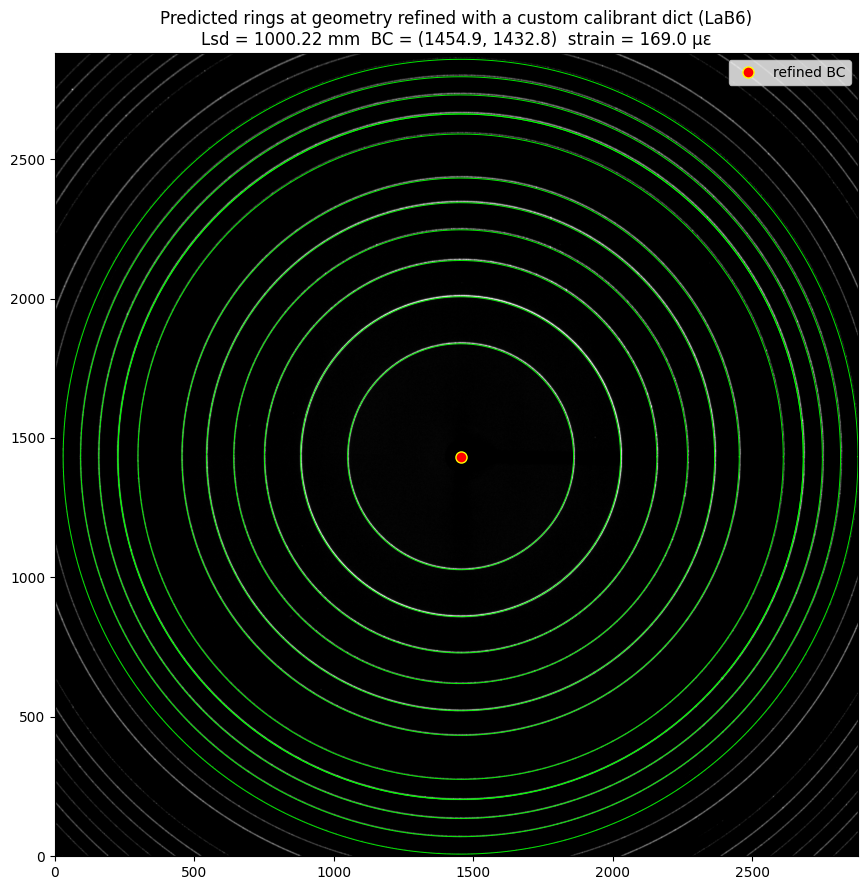

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from pathlib import Path
import math
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from midas_calibrate_v2 import calibrate
from midas_calibrate_v2.seed.auto_seed import make_seed
from midas_hkls import SpaceGroup, Lattice, generate_hkls

# Load the calibrant image. Self-contained: this cell can be run without
# running any earlier cells in the notebook. This dataset has no dark frame.
DATA = Path(os.environ.get(
    'V2_ONESHOT_FILE',
    '/Users/dbeniwal/ANL-research/github/MIDAS/scratch/test_calibrate_v2/data/ANLXRD00007_pos0.tif',
))
assert DATA.exists(), f'set V2_ONESHOT_FILE or update the DATA path; missing {DATA}'

img = tifffile.imread(DATA).astype(np.float32)
dark = None

WAVELENGTH_A = 0.2522   # Å — from data/info.txt
PX_UM        = 150.0    # µm — from data/info.txt

# Custom calibrant, described purely by lattice + space group — no name lookup.
# LaB6: SG 221, a = 4.15704 Å (values from data/info.txt).
custom_calibrant = {'a': 4.15704, 'sg': 221}

# Step 1 — compute a robust (BC, Lsd) seed from the same image already loaded above.
seed = make_seed(
    img,
    wavelength_A = WAVELENGTH_A,
    px_um        = PX_UM,
    calibrant    = custom_calibrant,   # dict instead of a named string
    use_diplib   = False,              # diplib's median filter segfaults on macOS
    # Optional tuning knobs (defaults work for most images):
    # snr_threshold       = 4.0,   # σ multiplier; lower → more arcs detected
    # bright_fraction_cap = 0.01,  # cap bright pixels at top 1 % of residual
    # min_arc_fraction    = 0.10,  # min arc length = 10 % of smallest image dim
    # dilation_radius     = 0,     # >0 bridges gaps in fragmented arcs
)
print(seed)
print()
print(f'  BC_y (column) = {seed.BC_y:.2f} px')
print(f'  BC_z (row)    = {seed.BC_z:.2f} px')
print(f'  Lsd           = {seed.Lsd_um / 1000:.3f} mm')
print(f'  calibrant_name = {seed.calibrant_name!r}  (placeholder — do not feed back as a name)')

# Step 2 — re-run calibrate() with the seed, bypassing the built-in seeder.
# Note: calibrant is the same dict, not the "<custom>" placeholder from seed.calibrant_name.
result_custom = calibrate(
    img,
    wavelength   = WAVELENGTH_A,
    pxY          = PX_UM,
    dark         = dark,
    calibrant    = custom_calibrant,   # ← dict, not a name
    initial_BC_y = seed.BC_y,          # ← from make_seed
    initial_BC_z = seed.BC_z,          # ← from make_seed
    initial_Lsd  = seed.Lsd_um,        # ← from make_seed
    output_dir   = './calib_out',
)

print()
print(f'Lsd  = {result_custom.Lsd / 1000:.4f} mm')
print(f'BC   = ({result_custom.BC_y:.2f}, {result_custom.BC_z:.2f}) px')
print(f'ty   = {result_custom.ty:+.4f}°   tz = {result_custom.tz:+.4f}°')
_s = (f'{result_custom.in_loop_strain_uE:.1f} µε'
      if result_custom.in_loop_strain_uE is not None else 'n/a')
print(f'in-loop strain = {_s}')

# Step 3 — visual check (same as section 4/8), using the custom-calibrant lattice for hkls.
refs = generate_hkls(
    SpaceGroup.from_number(custom_calibrant['sg']),
    Lattice(a=custom_calibrant['a'], b=custom_calibrant['a'], c=custom_calibrant['a'],
            alpha=90., beta=90., gamma=90.),
    wavelength_A=result_custom.wavelength_A, two_theta_max_deg=14.0,
)
ring_R3 = [result_custom.Lsd * math.tan(math.radians(r.two_theta_deg))
           / result_custom.pxY for r in refs]

img_d = np.clip(img - dark, 0, None) if dark is not None else img.copy()
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(np.log1p(img_d.clip(min=1)), origin='lower', cmap='gray',
          vmin=np.log1p(np.percentile(img_d[img_d > 0], 60)),
          vmax=np.log1p(np.percentile(img_d[img_d > 0], 99.95)))
th = np.linspace(0, 2 * np.pi, 360)
for r in ring_R3[:12]:
    if 0 < r < max(result_custom.NrPixelsY, result_custom.NrPixelsZ):
        ax.plot(result_custom.BC_y + r * np.cos(th),
                result_custom.BC_z + r * np.sin(th),
                '-', color='lime', lw=0.7, alpha=0.9)
ax.plot(result_custom.BC_y, result_custom.BC_z,
        'ro', ms=8, mec='yellow', label='refined BC')
ax.set_title(
    f'Predicted rings at geometry refined with a custom calibrant dict (LaB6)\n'
    f'Lsd = {result_custom.Lsd / 1000:.2f} mm  '
    f'BC = ({result_custom.BC_y:.1f}, {result_custom.BC_z:.1f})  '
    f'strain = {_s}')
ax.set_xlim(0, result_custom.NrPixelsY)
ax.set_ylim(0, result_custom.NrPixelsZ)
ax.legend()
plt.tight_layout()
plt.show()